## Import

In [1]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

import spaghetti
import libpysal
import esda
import numpy as np

from sklearn.cluster import KMeans
import networkx as nx
import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from shapely.geometry import LineString

D:\software\Anaconda\lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


## 1. Task A (spatial networks and planarity)

#### Read and merge datasets

In [2]:
df_2009 = pd.read_csv(r'datasets/Part2/2009.csv')
df_2010 = pd.read_csv(r'datasets/Part2/2010.csv')
df_2011 = pd.read_csv(r'datasets/Part2/2011.csv')
df_2012 = pd.read_csv(r'datasets/Part2/2012.csv')
df_2013 = pd.read_csv(r'datasets/Part2/2013.csv')
df_2014 = pd.read_csv(r'datasets/Part2/2014.csv')
df_2015 = pd.read_csv(r'datasets/Part2/2015.csv')
df_2016 = pd.read_csv(r'datasets/Part2/2016.csv')

df_all = pd.concat([df_2009, df_2010, df_2011, df_2012, df_2013, df_2014, df_2015, df_2016], ignore_index=True)

df_all.to_csv(r'datasets/Part2/2009-2016.csv', index=False, encoding='utf-8-sig')

print("Saved Successfully")
print(df_all.head())
print(df_all.shape)

Saved Successfully
  Reference Number  Grid Ref: Easting  Grid Ref: Northing  Number of Vehicles  \
0             3309             429093              436258                   1   
1             2609             434723              435534                   1   
2             2809             441173              433047                   1   
3             3809             428487              431364                   1   
4             3909             425928              435480                   2   

  Accident Date  Time (24hr) 1st Road Class Road Surface  \
0      1-Jan-09           55   Unclassified          Dry   
1      2-Jan-09         2335   Unclassified          Dry   
2      2-Jan-09         1645   Unclassified          Dry   
3      2-Jan-09         1723              A          Dry   
4      2-Jan-09         1350   Unclassified          Dry   

                       Lighting Conditions       Weather Conditions  \
0  Darkness: street lights present and lit  Fine without high 

#### Obtain the motorway network covering 1 square kilometre of Leeds centre

The base road network was extracted using OSMnx from a 570-meter radius around the Leeds center coordinates (53.7998, -1.5482). The extraction was strictly filtered to isolate vehicular traffic routes. To enable accurate, metric-based spatial calculations, the geometric graph was reprojected from standard geographic coordinates to the British National Grid (EPSG:27700).

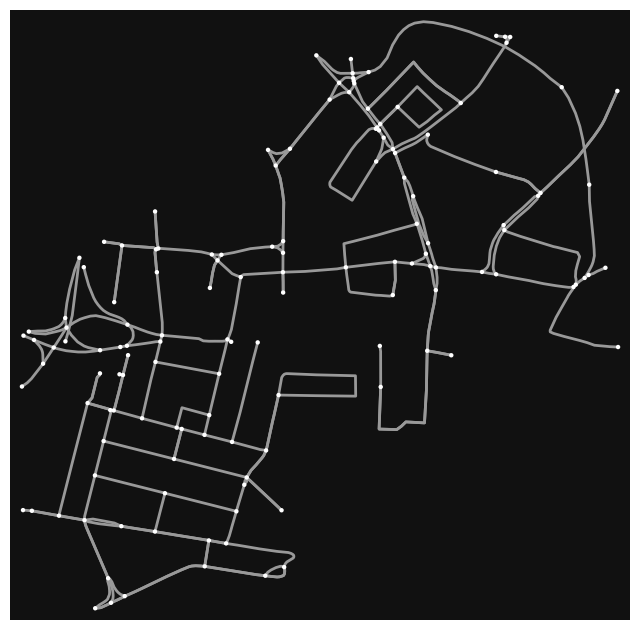

In [3]:
# The coordinates of Leeds centre
leeds_center = (53.7998, -1.5482)
dist=570

G = ox.graph_from_point(
    leeds_center, 
    dist=570, 
    network_type='drive'
)

# Visualisation
fig, ax = ox.plot_graph(G, node_size=10, edge_linewidth=2)

### What are the coordinates of the chosen area?

In [40]:
west, south, east, north = ox.utils_geo.bbox_from_point(leeds_center, dist)
print(f"Chosen Area Coordinates: North: {north}, South: {south}, East: {east}, West: {west}")

Chosen Area Coordinates: North: 53.80492612591231, South: 53.794673874087685, East: -1.539520602315463, West: -1.556879397684537


### What are the characteristics of this road network? Include, at least, the spatial diameter of the network, the average street length, node density, intersection density, and edge density.

In [5]:
stats = ox.basic_stats(G, area=ox.projection.project_graph(G).graph['area'] if 'area' in G.graph else (dist*2)**2)

# Spatial Diameter
if nx.is_strongly_connected(G):
    diameter = nx.diameter(G, weight='length')
else:
    G_sub = G.subgraph(max(nx.weakly_connected_components(G), key=len))
    diameter = nx.diameter(G_sub.to_undirected(), weight='length')

# Specific indicators
avg_street_length = stats['street_length_avg']
node_density = stats['node_density_km']
intersection_density = stats['intersection_density_km']
edge_density = stats['edge_density_km']

print("=== Characteristics of the road network ===")
print(f"Spatial Diameter: {diameter:.2f} meters")
print(f"Average Street Length: {avg_street_length:.2f} meters")
print(f"Node Density: {node_density:.2f} /sq km")
print(f"Intersection Density: {intersection_density:.2f} /sq km")
print(f"Edge Density: {edge_density:.2f} /sq km")

=== Characteristics of the road network ===
Spatial Diameter: 1820.21 meters
Average Street Length: 72.58 meters
Node Density: 106.19 /sq km
Intersection Density: 95.41 /sq km
Edge Density: 13062.18 /sq km


**Spatial Diameter (1820.21 m)**: The longest shortest-path within this 1 km² area is approximately 1.82 km. This indicates that physical navigability is constrained by the actual urban block morphology rather than by direct linear paths.

**Average Street Length (72.58 m)**: This extremely short segment length indicates a fine-grained street network with high intersection frequency, typical of commercial city centres.

**Network Densities**: The node density (106.19 / km²) and intersection density (95.41 / km²) are remarkably close. This demonstrates that the vast majority of topological nodes serve as functional intersections rather than redundant geometric artifacts. Supported by a high edge density (13,062.18 / km²), the network exhibits excellent spatial connectivity and road capacity.

### What is the average circuitry of the network? What does this tell you about the efficiency of using roads in this area?

In [6]:
avg_circuity = stats['circuity_avg']
print(f"Average Circuitry: {avg_circuity:.4f}")

Average Circuitry: 1.1241


Efficiency: A value of 1.1241 indicates that **navigating this area requires, on average, only a 12.4% detour from a direct line**. This indicates a highly efficient road layout in which drivers do not encounter severe topological bottlenecks or major detours.

Morphology: However, because the value is not exactly 1.0, it realistically captures the slight routing deviations caused by local road curvatures, one-way systems, and irregular historical street blocks inherent to the Leeds city centre.

### Is the network planar? Why/why not? Provide examples and argue your answer considering the conditions of planarity.

In [7]:
is_planar, _ = nx.check_planarity(G)
print(f"Is the network planar? {is_planar}")

Is the network planar? True


In the context of an urban drive network, planarity means that roads intersect almost exclusively at grade. The extraction did not capture any complex grade-separated structures, such as multi-level interchanges or crossing tunnels where roads cross geometrically but not topologically.

#### Load and process road traffic accident data 

Accident records from 2009 to 2016 were concatenated into a comprehensive longitudinal dataset. Essential geographic fields (Grid Ref: Easting and Grid Ref: Northing) were purged of null values to guarantee spatial integrity before generating Point geometries.

In [8]:
accidents_df = pd.read_csv('datasets/Part2/2009-2016.csv')

accidents_df = accidents_df.dropna(subset=['Grid Ref: Easting', 'Grid Ref: Northing'])

# Convert a Pandas DataFrame to a GeoDataFrame
geometry = [Point(xy) for xy in zip(accidents_df['Grid Ref: Easting'], accidents_df['Grid Ref: Northing'])]
gdf_accidents = gpd.GeoDataFrame(accidents_df, geometry=geometry)

gdf_accidents.set_crs(epsg=27700, inplace=True)

,Reference Number,Grid Ref: Easting,Grid Ref: Northing,Number of Vehicles,Accident Date,Time (24hr),1st Road Class,Road Surface,Lighting Conditions,Weather Conditions,Casualty Class,Casualty Severity,Sex of Casualty,Age of Casualty,Type of Vehicle,geometry
0,3309,429093,436258,1,1-Jan-09,55,Unclassified,Dry,Darkness: street lights present and lit,Fine without high winds,Pedestrian,Slight,Male,44,Car,POINT (429093 436258)
1,2609,434723,435534,1,2-Jan-09,2335,Unclassified,Dry,Darkness: street lights present and lit,Fine without high winds,Driver,Serious,Female,23,Car,POINT (434723 435534)
2,2809,441173,433047,1,2-Jan-09,1645,Unclassified,Dry,Darkness: street lights present and lit,Fine without high winds,Pedestrian,Slight,Female,12,Car,POINT (441173 433047)
3,3809,428487,431364,1,2-Jan-09,1723,A,Dry,Darkness: street lights present and lit,Fine without high winds,Pedestrian,Slight,Male,15,Car,POINT (428487 431364)
4,3909,425928,435480,2,2-Jan-09,1350,Unclassified,Dry,Daylight: street lights present,Fine without high winds,Driver,Slight,Female,34,Car,POINT (425928 435480)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21430,3CV1171,423815,434248,2,31/12/2016,1850,Unclassified,Wet / Damp,Darkness: street lights present and lit,Fine without high winds,Driver or rider,Slight,Male,29,Motorcycle over 50cc and up to 125cc,POINT (423815 434248)
21431,3CV1423,427102,427700,2,31/12/2016,2155,Unclassified,Wet / Damp,Darkness: street lights present and lit,Fine without high winds,Driver or rider,Slight,Female,30,Car,POINT (427102 427700)
21432,4160976,419983,440944,2,06/12/2016,1601,A,Dry,Darkness: street lights present and lit,Fine without high winds,Driver or rider,Serious,Female,47,Car,POINT (419983 440944)
21433,4160976,419983,440944,2,06/12/2016,1601,A,Dry,Darkness: street lights present and lit,Fine without high winds,Pedestrian,Slight,Male,29,Car,POINT (419983 440944)


#### Identify accident blackspots on roads for driving 

A convex hull bounding box of the projected road nodes was generated to geographically clip the accident dataset. To associate accidents with specific street segments for topological analysis, a spatial join (*sjoin_nearest*) was executed. This algorithm snapped each accident point to the nearest road edge within a maximum tolerance of 20 metres. Duplicate matches were resolved by retaining the first geometry instance, resulting in exactly 471 topologically mapped and verified accidents ready for spatial network evaluation.

In [9]:
G_projected = ox.project_graph(G, to_crs="EPSG:27700")

nodes_proj, edges_proj = ox.graph_to_gdfs(G_projected)

bbox_polygon = nodes_proj.unary_union.convex_hull
accidents_in_bbox = gpd.clip(gdf_accidents, bbox_polygon)

accidents_on_road = gpd.sjoin_nearest(
    accidents_in_bbox,
    edges_proj,
    how="inner",
    max_distance=20,
    distance_col="dist_to_road"
)

accidents_on_road = accidents_on_road[~accidents_on_road.index.duplicated(keep='first')]

C:\Users\99371\AppData\Local\Temp\ipykernel_20456\2239607053.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbox_polygon = nodes_proj.unary_union.convex_hull


#### Check whether the number of accidents has reached 300

In [10]:
accident_count = len(accidents_on_road)

print(f"After screening, the total number of traffic accidents was {accident_count}.")
print("")

if accident_count >= 300:
    print("The total number of accidents over the years is no fewer than 300.")
else:
    print("The total number of incidents over the years is less than 300.")

After screening, the total number of traffic accidents was 471.

The total number of accidents over the years is no fewer than 300.


## 2. Task B (road accidents)

### Visualisation

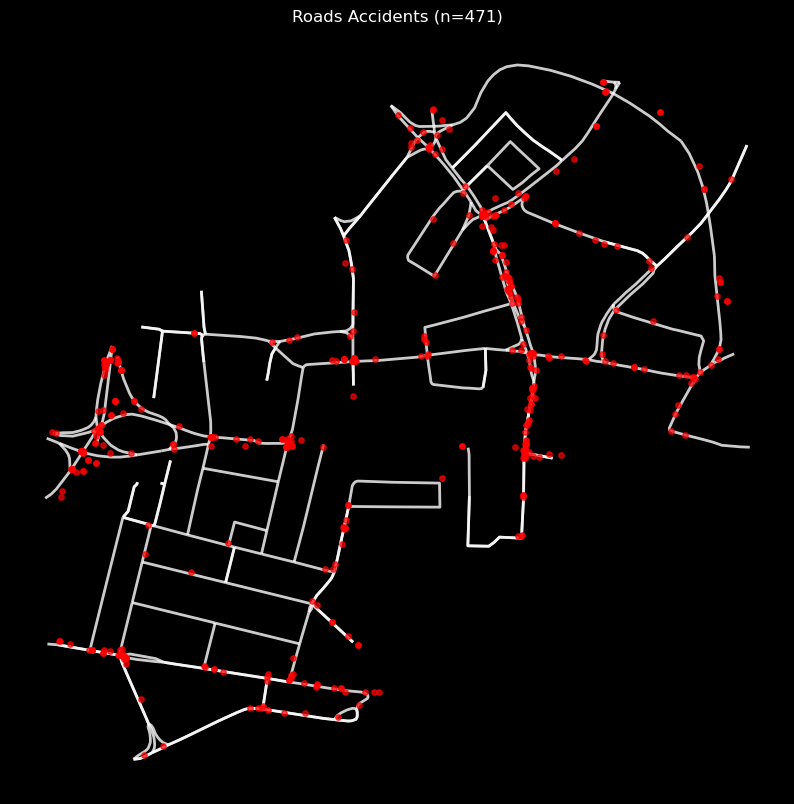

In [12]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
ax.set_facecolor('black')

edges_proj.plot(ax=ax, linewidth=2, edgecolor='white', alpha=0.8)

accidents_on_road.plot(ax=ax, color='red', markersize=15, alpha=0.7, zorder=999)

ax.axis('off')
plt.title(f"Roads Accidents (n={accident_count})", color='white')
plt.show()

Accidents are not uniformly or randomly scattered across the spatial extent; rather, they exhibit strong clustering tendencies along specific topological structures.

The visualisation reveals high-density accident clusters in three primary categories of locations:

**Central Arterial Axis**: Accidents are highly concentrated on the main north-south roads in this area.

**Complex Junction Zones**: Severe clustering in the north-central sector, characterised by intricate road merging and diverging topologies.

**Western Interchanges**: A high frequency of incidents on the dense roundabout and slip-road configurations located on the western periphery.

Conversely, peripheral branch roads, highly curved local segments, and minor residential streets demonstrate significantly lower accident frequencies. This stark spatial heterogeneity suggests that **accident occurrences are intrinsically linked to network centrality, higher traffic throughput (main connecting axes), and topological complexity (frequent intersections), rather than occurring evenly across the urban grid**.


#### Investigate whether a high number of accidents on one road correlates with a high number on connecting roads. Calculate the k-function and the Moran's I values for the above spatial graph. What inferences can you draw from this analysis?

#### Pre-processing for road network matching

In [13]:
net = spaghetti.Network(in_data=edges_proj)
net.snapobservations(accidents_on_road, name='accidents')

D:\software\Anaconda\lib\site-packages\spaghetti\network.py:3412: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  pts = [cg.shapes.Point((p.x, p.y)) for p in pts_objs]
D:\software\Anaconda\lib\site-packages\spaghetti\util.py:572: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  return cg.Chain([cg.Point(_vcoords[v]) for v in _vs] if _vcoords else _vs)
D:\software\Anaconda\lib\site-packages\libpysal\cg\shapes.py:1025: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._bounding_box = Rectangle(


### Investigate whether accidents happen nearer to intersections or partway along roads. Consider this as asking at what fraction of the road length away from the nearest intersection do accidents typically occur.

#### Analysis of the Moran’s I Index

In [14]:
edges_proj_reset = edges_proj.reset_index()

accidents_mapped = gpd.sjoin_nearest(
    accidents_on_road,
    edges_proj_reset,
    how="inner",
    max_distance=20
)

edge_counts = accidents_mapped['index_right'].value_counts()

edges_proj_reset['accident_count'] = edge_counts
edges_proj_reset['accident_count'] = edges_proj_reset['accident_count'].fillna(0) # 没事故的填0

# Create the spatial weight matrix W 
w = libpysal.weights.Queen.from_dataframe(edges_proj_reset)

# Calculate Moran's I
moran = esda.Moran(edges_proj_reset['accident_count'], w)

print(f"Moran's I index: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")

Moran's I index: 0.3395
P-value: 0.0010


C:\Users\99371\AppData\Local\Temp\ipykernel_20456\3627370271.py:16: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(edges_proj_reset)


The calculated Moran's I value is **0.3395** with a highly significant p-value of **0.0010**. If accidents were randomly distributed across the network edges, the index would approach zero. The positive value and low p-value statistically confirm the presence of strong positive spatial autocorrelation. Overall, **high-accident street segments are topologically adjacent to one another, forming concentrated risk zones rather than being randomly dispersed**.

#### Network K-Function Analysis

In [15]:
distance_bands = np.linspace(0, 1000, 20) 

k_results = net.GlobalAutoK(net.pointpatterns['accidents'], nsteps=20)

print("The K-Function calculation is complete.")

The K-Function calculation is complete.


Analysis range (metres):
[   0.           95.72683899  191.45367797  287.18051696  382.90735595
  478.63419493  574.36103392  670.0878729   765.81471189  861.54155088
  957.26838986 1052.99522885 1148.72206784 1244.44890682 1340.17574581
 1435.9025848  1531.62942378 1627.35626277 1723.08310175 1818.80994074]

Corresponding observed K-values:
[    0.           706.00846367  1495.56968321  2333.06898834
  3400.27675504  4483.25849334  5478.37428041  6586.24931766
  7501.26290515  8332.23080017  9448.60899399 10678.36260875
 11619.50183672 12615.84996533 13121.84939836 13410.34055099
 13545.15871459 13613.55366962 13637.58432949 13640.04901255]


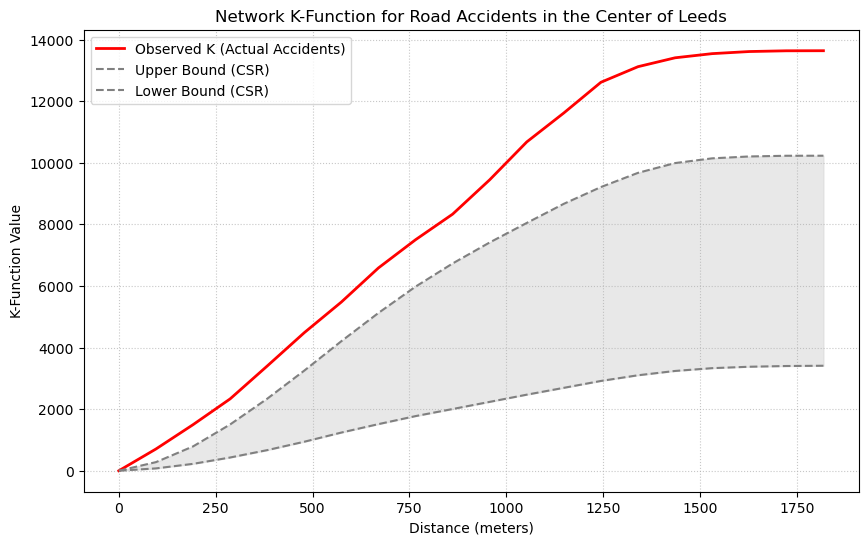

In [16]:
# Extract values
distances = k_results.xaxis
observed_k = k_results.observed

print("Analysis range (metres):")
print(distances)
print("\nCorresponding observed K-values:")
print(observed_k)

# Plot a K-function graph
plt.figure(figsize=(10, 6))

plt.plot(distances, observed_k, label='Observed K (Actual Accidents)', color='red', linewidth=2)

if hasattr(k_results, 'upperenvelope') and hasattr(k_results, 'lowerenvelope'):
    plt.plot(distances, k_results.upperenvelope, label='Upper Bound (CSR)', color='gray', linestyle='--')
    plt.plot(distances, k_results.lowerenvelope, label='Lower Bound (CSR)', color='gray', linestyle='--')
    plt.fill_between(distances, k_results.lowerenvelope, k_results.upperenvelope, color='lightgray', alpha=0.5)

plt.title('Network K-Function for Road Accidents in the Center of Leeds')
plt.xlabel('Distance (meters)')
plt.ylabel('K-Function Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**K-curve (red line) remains strictly above the upper envelope of the simulated Complete Spatial Randomness (CSR area).** This deviation indicates that traffic accidents exhibit significant spatial clustering within this distance range. **Accidents tend to cluster rather than occur at random**, indicating that specific road segments or contiguous areas are hotspots for traffic accidents.

#### Investigate whether accidents happen nearer to intersections or partway along roads. Consider this as asking at what fraction of the road length away from the nearest intersection do accidents typically occur.

In [17]:
fractions = []

acc_pattern = net.pointpatterns['accidents']

for arc, obs_dict in acc_pattern.obs_to_arc.items():
    
    node_A = arc[0] 
    
    edge_length = net.arc_lengths[arc]
    
    if edge_length <= 0.001:
        continue 
        
    for obs_id in obs_dict.keys():
        
        dist_from_start_node = acc_pattern.dist_to_vertex[obs_id][node_A]

        fraction_from_start = dist_from_start_node / edge_length

        fraction_from_start = max(0.0, min(1.0, fraction_from_start))

        nearest_intersection_fraction = min(fraction_from_start, 1.0 - fraction_from_start)
        
        fractions.append(nearest_intersection_fraction)

print(f"The location ratios for {len(fractions)} accident spots have been successfully calculated.")

The location ratios for 471 accident spots have been successfully calculated.


#### Statistical Summary of Accident Locations

In [43]:
frac_array = np.array(fractions)

# Mean, Median and Total
mean_frac = np.mean(frac_array)
median_frac = np.median(frac_array)
total_accidents = len(frac_array)

# Ratio
count_near_intersection = np.sum(frac_array <= 0.25)
percentage_near = (count_near_intersection / total_accidents) * 100
count_mid_block = np.sum(frac_array > 0.25)
percentage_mid = (count_mid_block / total_accidents) * 100

print("=== Statistical Summary of Accident Locations ===")
print(f"Mean distance fraction: {mean_frac:.4f}")
print(f"Median distance fraction: {median_frac:.4f}")
print(f"Near Intersections (<= 0.25): {count_near_intersection} accidents ({percentage_near:.2f}%)")
print(f"Partway along roads (> 0.25): {count_mid_block} accidents ({percentage_mid:.2f}%)")

=== Statistical Summary of Accident Locations ===
Mean distance fraction: 0.2268
Median distance fraction: 0.2153
Near Intersections (<= 0.25): 262 accidents (55.63%)
Partway along roads (> 0.25): 209 accidents (44.37%)


A fraction of 0.0 indicates an accident precisely at an intersection, while 0.5 denotes the exact midpoint of the road.

The analysis yields a mean fractional distance of 0.2268 and a median of 0.2153. By setting a logical threshold of 0.25, representing the quarter mark of the street, the proportional distribution is as follows:

**55.63% of accidents occur near intersections**, with a fraction less than 0.25.

**44.37% of accidents occur in the mid-block**, with a fraction between 0.25 and 0.5.


#### Plot a histogram

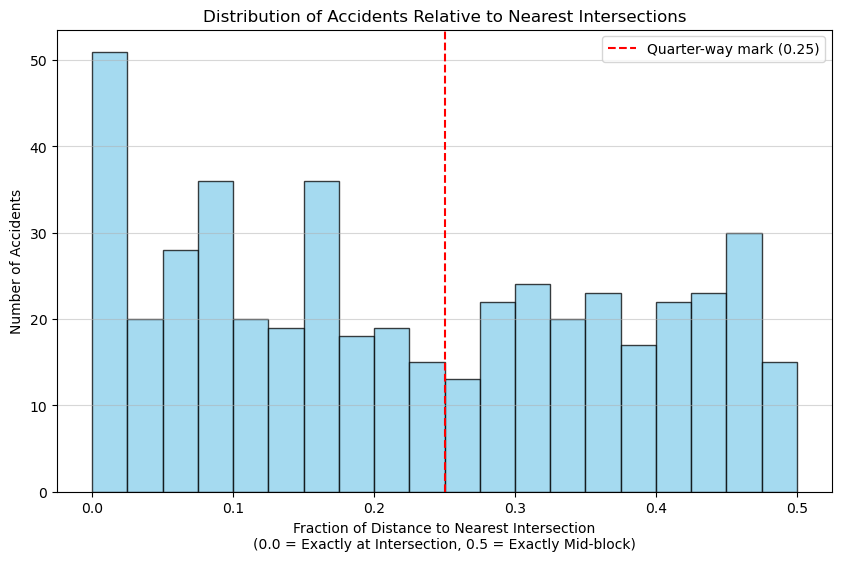

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(fractions, bins=20, range=(0, 0.5), edgecolor='black', alpha=0.75, color='skyblue')

plt.title("Distribution of Accidents Relative to Nearest Intersections")
plt.xlabel("Fraction of Distance to Nearest Intersection\n(0.0 = Exactly at Intersection, 0.5 = Exactly Mid-block)")
plt.ylabel("Number of Accidents")
plt.grid(axis='y', alpha=0.5)

plt.axvline(x=0.25, color='red', linestyle='--', label='Quarter-way mark (0.25)')
plt.legend()

plt.show()

**The histogram reveals a distinct peak near the 0.0 mark**, indicating that a substantial number of accidents are concentrated immediately adjacent to intersections. This reflects the intense hazards of nodal conflicts, such as vehicle turning, merging, yielding, and signal control.

However, the histogram also shows a considerable, **sustained distribution of accidents across the 0.25 to 0.5 range**. This visual evidence, together with the fact that nearly 45 percent of incidents occur in this mid-block zone, indicates that the risk does not decline sharply as one moves away from the node. Therefore, the network exhibits a mixed risk topology. While intersections remain the primary hazard zones, edge-specific dynamics, such as continuous driving, lane changes, or speed variations along main traffic corridors, create a sustained structural risk across the entire road segment.

These results suggest that road safety policy should cover both **intersections** and **road segments**. As accidents cluster near intersections, priority should be given to reducing nodal conflicts with improved signal control, clearer lane markings, and safer turning design. Meanwhile, the mid-block also needs corridor-based interventions such as speed management, better visibility, and monitoring along major traffic streets.

## 3. Task C (Voronoi diagrams)

### Select the initial set of 4 cell seed points. For this, you can use several criteria, such as being far away from frequent accident roads, being close to public transport, being evenly spread, etc. (explain your choice in the report).

### Identify and eliminate high-risk accident spots

In [19]:
dangerous_edges = edges_proj_reset[edges_proj_reset['accident_count'] >= 1]

if 'u' in dangerous_edges.columns and 'v' in dangerous_edges.columns:
    dangerous_nodes = set(dangerous_edges['u']).union(set(dangerous_edges['v']))
else:
    dangerous_nodes = set(dangerous_edges['level_0']).union(set(dangerous_edges['level_1']))

safe_nodes = nodes_proj[~nodes_proj.index.isin(dangerous_nodes)].copy()

print(f"Total number of nodes: {len(nodes_proj)}, Number of secure nodes: {len(safe_nodes)}")

Total number of nodes: 138, Number of secure nodes: 24


### Use the Closeness Centrality algorithm to find 4 evenly distributed cluster centres amongst the secure nodes

In [20]:
N_marathons = 4

# Runners do not need to follow the ‘one-way’ rules that apply to cars
G_undirected = G_projected.to_undirected()

closeness = nx.closeness_centrality(G_undirected)

safe_nodes = safe_nodes.copy()
safe_nodes['closeness'] = safe_nodes.index.map(closeness)
safe_nodes_sorted = safe_nodes.sort_values(by='closeness', ascending=False)

### Identify the actual safe nodes closest to these 4 theoretical centres as the final seed points

In [25]:
seed_node_ids = []
seed_points_geom = []
min_distance = 400

for node_id, row in safe_nodes_sorted.iterrows():
    if len(seed_node_ids) < N_marathons:
        point_current = row.geometry
        
        is_far_enough = True
        for existing_geom in seed_points_geom:
            if point_current.distance(existing_geom) < min_distance:
                is_far_enough = False
                break
        
        if is_far_enough:
            seed_node_ids.append(node_id)
            seed_points_geom.append(point_current)
    else:
        break

seeds_gdf = gpd.GeoDataFrame({'node_id': seed_node_ids}, geometry=seed_points_geom, crs=nodes_proj.crs)

print(f"{N_marathons} seed points for the marathon zones have been successfully selected.")
print("Seed node IDs:", seed_node_ids)

4 seed points for the marathon zones have been successfully selected.
Seed node IDs: [1862252964, 163639554, 3871120536, 3784990282]


### Visualisation

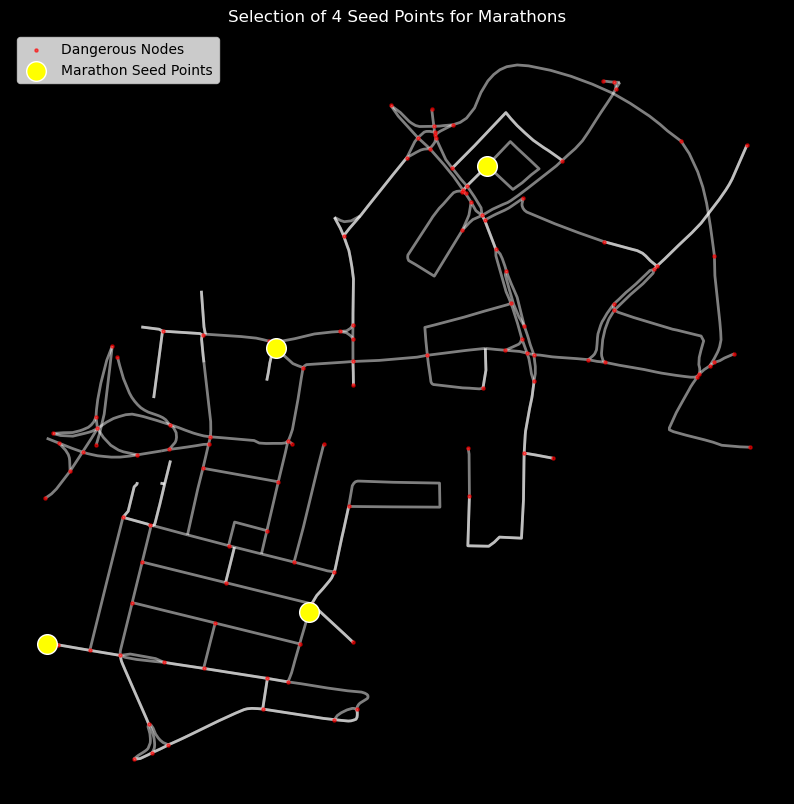

In [26]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
ax.set_facecolor('black')

edges_proj_reset.plot(ax=ax, linewidth=2, edgecolor='white', alpha=0.5)

nodes_proj.loc[list(dangerous_nodes)].plot(ax=ax, color='red', markersize=5, alpha=0.6, label='Dangerous Nodes', zorder=999)

seeds_gdf.plot(ax=ax, color='yellow', marker='o', markersize=200, edgecolor='white', label='Marathon Seed Points', zorder=999)

plt.title("Selection of 4 Seed Points for Marathons", color='white')
ax.axis('off')
plt.legend()
plt.show()

To partition the road network for the marathon event, four initial seed nodes were selected: 1862252964, 163639554, 3871120536, and 3784990282. Rather than relying on random sampling, these seeds were identified using a deterministic, three-tier heuristic strategy that balances safety, network accessibility, and spatial dispersion.

First, **safety was prioritized by establishing a strict exclusion parameter**. Any topological node connected to a street segment with one or more recorded accidents was classified as a hazard and removed from the candidate pool. This ensures the marathon hubs originate exclusively in demonstrably safe zones.

Second, to maximize network accessibility, **the remaining safe nodes were ranked by their closeness centrality**. Selecting nodes with high closeness ensures that the core of each marathon cell is well connected to its surrounding local subnetwork, directly supporting the mayoral objective of facilitating convenient participation by local residents.

Third, to ensure spatial dispersion and prevent seeds from clustering within a single safe neighborhood, **a minimum network distance constraint of 400 meters was enforced during the selection process**. This spatial constraint ensures that the four hubs are evenly distributed across sectors of the study area, providing a structurally balanced foundation for subsequent spatial partitioning.

### Visualise the cells yield by your selection of seed points in a Voronoi diagram. What kind of Voronoi diagram (edge planar, node network, or edge points network) is most useful for this problem, and why?

### Visualise the cells generated from seed points

In [27]:
# Remove self-loop
G_projected.remove_edges_from(nx.selfloop_edges(G_projected))

G_undirected = G_projected.to_undirected()

# Calculate the network distance from each node to the nearest seed node
lengths, paths = nx.multi_source_dijkstra(G_undirected, sources=seed_node_ids, weight='length')

node_to_seed = {node: path[0] for node, path in paths.items()}

colors = ['cyan', 'magenta', 'lime', 'orange']
seed_to_color = {seed: colors[i] for i, seed in enumerate(seed_node_ids)}

lines = []
edge_colors = []

for u, v, data in G_undirected.edges(data=True):
    closest_seed = node_to_seed.get(u)
    color = seed_to_color[closest_seed] if closest_seed is not None else 'darkgray'
    edge_colors.append(color)
    
    if 'geometry' in data:
        lines.append(data['geometry'])
    else:
        point_u = (G_undirected.nodes[u]['x'], G_undirected.nodes[u]['y'])
        point_v = (G_undirected.nodes[v]['x'], G_undirected.nodes[v]['y'])
        lines.append(LineString([point_u, point_v]))

colored_edges_gdf = gpd.GeoDataFrame(geometry=lines)
colored_edges_gdf['color'] = edge_colors

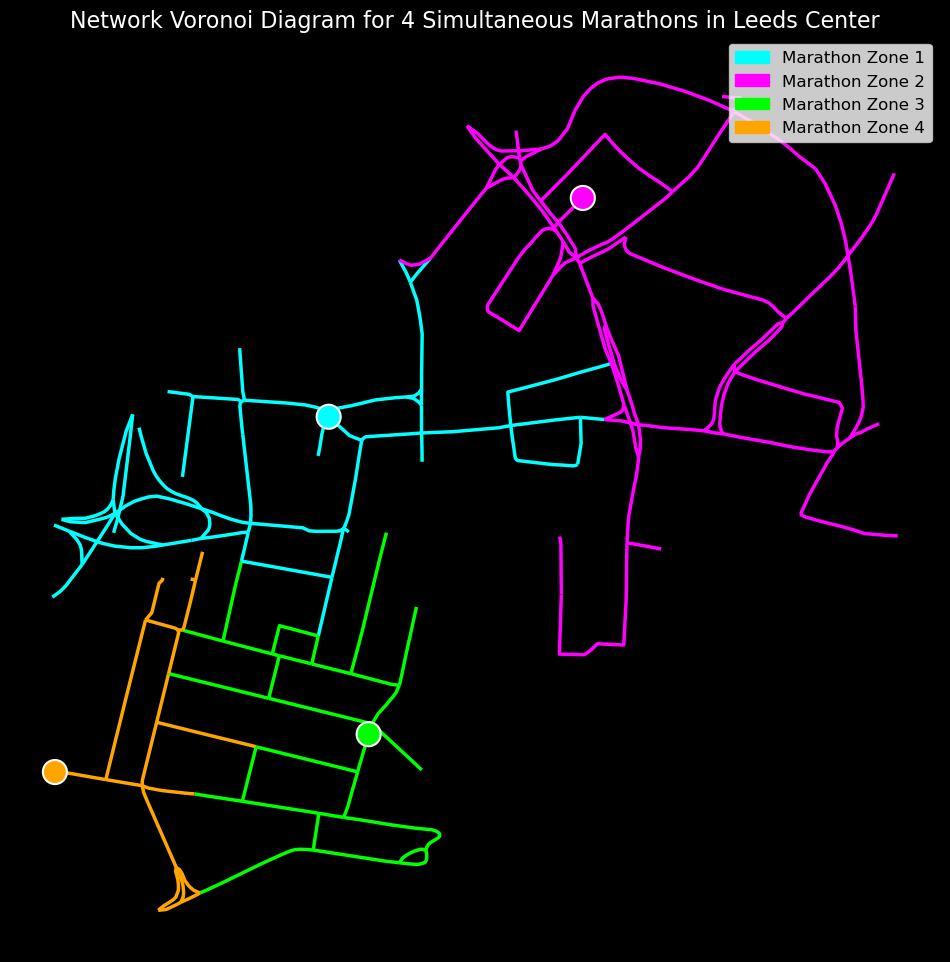

In [28]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.set_facecolor('black')

colored_edges_gdf.plot(
    ax=ax, 
    color=colored_edges_gdf['color'], 
    linewidth=2.5
)

pos = {node: (data['x'], data['y']) for node, data in G_undirected.nodes(data=True)}
seed_x = [pos[seed][0] for seed in seed_node_ids]
seed_y = [pos[seed][1] for seed in seed_node_ids]
ax.scatter(seed_x, seed_y, c=colors, marker='o', s=300, edgecolor='white', linewidths=1.5, zorder=5)

plt.title("Network Voronoi Diagram for 4 Simultaneous Marathons in Leeds Center", color='white', fontsize=16)
ax.axis('off')

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=colors[i], label=f'Marathon Zone {i+1}') for i in range(len(colors))]
plt.legend(handles=legend_patches, facecolor='white', loc='upper right', fontsize=12)

plt.show()

Based on four seed points, the road network was partitioned into four marathon cells, with respective road sub-networks coloured for visualisation. For this urban routing problem, the edge points network Voronoi diagram is the most useful classification model.

The selection rationale has three aspects. First, unlike the edge-planar Voronoi diagram, which partitions 2D space based on direct Euclidean distance, **the network Voronoi respects the physical city's topological constraints**. Runners and residents use actual streets, and planar distance ignores impassable blocks, curved roads, and disconnected segments, causing flawed routing.

Second, compared to the node-network Voronoi, **the edge-point network Voronoi is more accurate for marathon planning**. A node-based approach only assigns intersections to the nearest seed, oversimplifying long street midsections. Since a marathon route consists of edge lengths, the assignment must cover entire road segments, not just intersections.

Finally, **the edge points network approach aligns with the identification of a continuous 42-kilometer loop**. Assigning each drivable edge to a marathon zone creates precise, self-contained road clusters, enabling independent, accurate, and continuous path searching within each cell.

### Find 2 or 3 cells for which you can find at least one path that is approximately 42 km long and finishes at the same point where it starts. Visualise both the cells and the found paths.

#### Find a marathon path for two cells

In [29]:
cell_subgraphs = {}

for seed in seed_node_ids:
    nodes_in_cell = [n for n, s in node_to_seed.items() if s == seed]
    H = G_undirected.subgraph(nodes_in_cell).copy()
    cell_subgraphs[seed] = H

In [30]:
# Random walk + homing
def generate_marathon_path(H, start_node, target_length=42195, tolerance=200):
    """
    Generate a path on an undirected graph H,
    starting from start_node, with total length close to target_length.
    """
    if start_node not in H:
        return None, 0

    connected_components = list(nx.connected_components(H))
    component_nodes = max(connected_components, key=len)
    H_connected = H.subgraph(component_nodes).copy()

    if start_node not in H_connected:
        return None, 0

    current_node = start_node
    path = [current_node]
    current_length = 0

    max_attempts = 50000
    attempt = 0

    while attempt < max_attempts:
        neighbors = list(H_connected.neighbors(current_node))
        if not neighbors:
            break

        next_node = random.choice(neighbors)

        edge_data = H_connected.get_edge_data(current_node, next_node)

        if isinstance(edge_data, dict) and 0 in edge_data:
            length = edge_data[0].get('length', 10)
        elif isinstance(edge_data, dict) and all(isinstance(v, dict) for v in edge_data.values()):
            length = list(edge_data.values())[0].get('length', 10)
        else:
            length = edge_data.get('length', 10)

        path.append(next_node)
        current_length += length
        current_node = next_node

        if current_length > (target_length - 1500):
            try:
                path_home = nx.shortest_path(
                    H_connected, current_node, start_node, weight='length'
                )
                dist_home = nx.shortest_path_length(
                    H_connected, current_node, start_node, weight='length'
                )

                final_length = current_length + dist_home

                if abs(final_length - target_length) <= tolerance:
                    path.extend(path_home[1:])
                    return path, final_length

            except nx.NetworkXNoPath:
                pass

        attempt += 1

    return None, 0

In [31]:
selected_seeds = seed_node_ids[:2] 
found_paths = {}

for seed in selected_seeds:
    print(f"Calculating a 42km route for cell(seed {seed}) ......")
    subgraph = cell_subgraphs[seed]
    path, length = generate_marathon_path(subgraph, seed, target_length=42195, tolerance=200)
    
    if path:
        found_paths[seed] = path
        print(f" Path found! Total length: {length / 1000:.2f} km.")
    else:
        print(f"Finding failure.")

Calculating a 42km route for cell(seed 1862252964) ......
 Path found! Total length: 42.00 km.
Calculating a 42km route for cell(seed 163639554) ......
 Path found! Total length: 42.07 km.


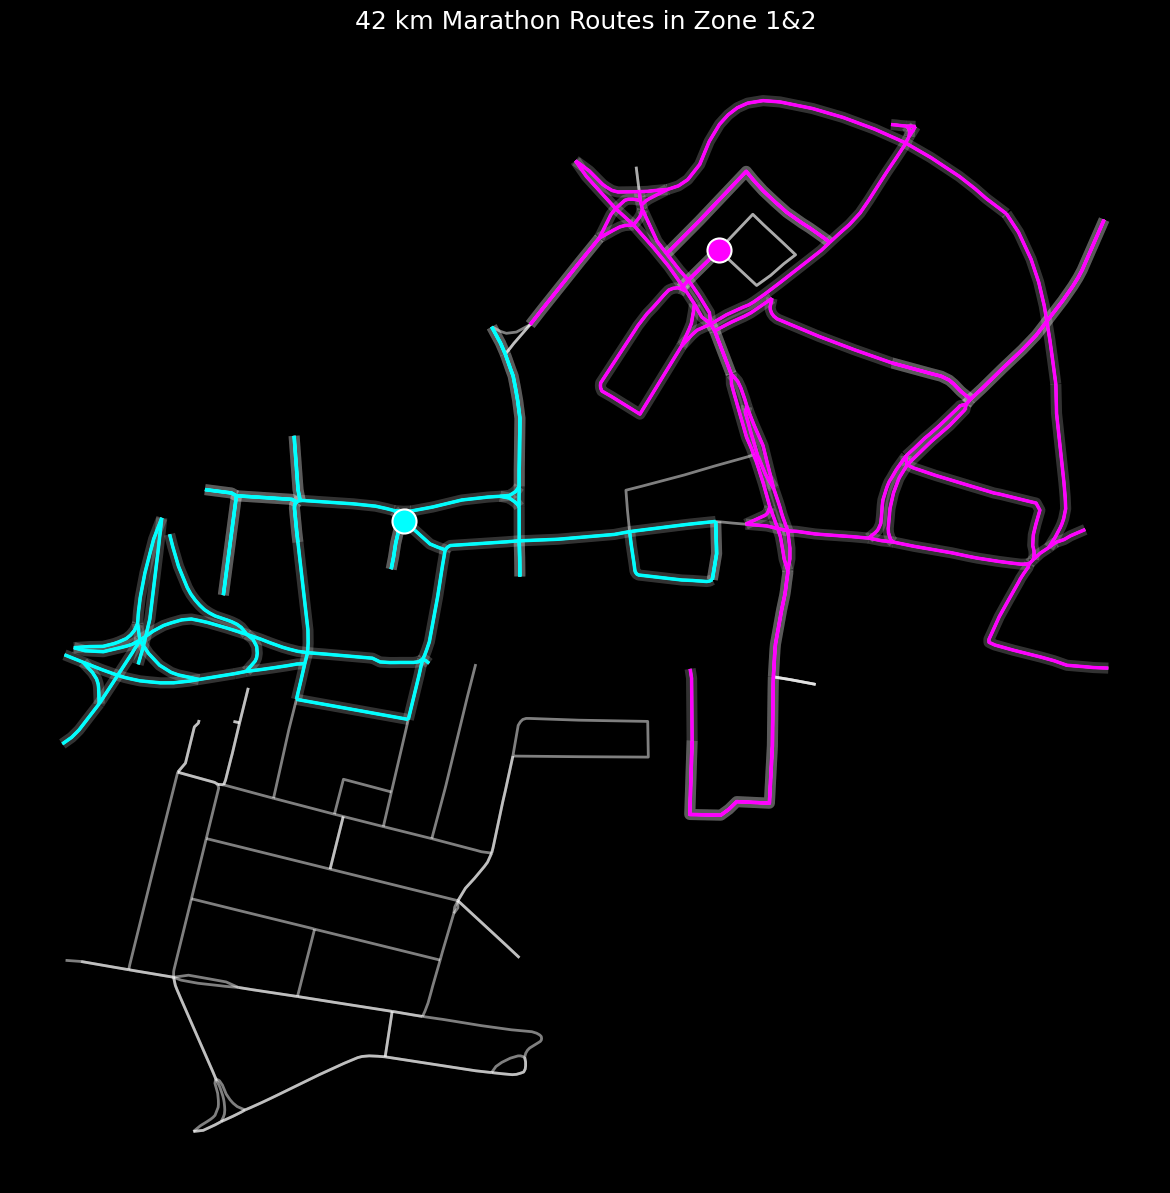

In [32]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.set_facecolor('black')

edges_proj_reset.plot(ax=ax, linewidth=2, edgecolor='white', alpha=0.5)

for seed in selected_seeds:
    if seed in found_paths:
        cell_color = seed_to_color[seed]

        subgraph = cell_subgraphs[seed]
        nodes_in_cell = set(subgraph.nodes())

        cell_edges_gdf = edges_proj_reset[
            edges_proj_reset['u'].isin(nodes_in_cell) &
            edges_proj_reset['v'].isin(nodes_in_cell)
        ].copy()

        cell_edges_gdf.plot(
            ax=ax,
            color='white',
            linewidth=2,
            alpha=0.35
        )

        path_nodes = found_paths[seed]
        path_edge_pairs = list(zip(path_nodes, path_nodes[1:]))

        path_edge_set = {tuple(sorted((u, v))) for u, v in path_edge_pairs}

        route_edges_gdf = cell_edges_gdf[
            cell_edges_gdf.apply(
                lambda row: tuple(sorted((row['u'], row['v']))) in path_edge_set,
                axis=1
            )
        ].copy()

        route_edges_gdf.plot(
            ax=ax,
            color='white',
            linewidth=8,
            alpha=0.2
        )

        route_edges_gdf.plot(
            ax=ax,
            color=cell_color,
            linewidth=2.5,
        )

        seed_point = nodes_proj.loc[[seed]]
        seed_point.plot(
            ax=ax,
            color=cell_color,
            markersize=300,
            edgecolor='white',
            linewidth=1.5,
            zorder=999
        )

plt.title("42 km Marathon Routes in Zone 1&2", color='white', fontsize=18, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

As visualised in the map, these two distinct routes are explicitly overlaid within their assigned spatial boundaries. The first route, depicted in cyan, operates entirely within the central western partition. The second route, depicted in magenta, is confined to the northern and eastern partition. Crucially, neither route breaches its designated cellular boundary. This spatial confinement demonstrates that the edge-point network Voronoi partitioning successfully isolates the road clusters, enabling independent, non-overlapping event routing.

### Try to extend the previous step to all cells. Can you find at least one such a path for every cell?

#### Find a marathon path for all cells

In [33]:
found_paths_all = {}

print("Starting to search for paths for the four marathon cells......")

for seed in seed_node_ids:
    print(f"Calculating a 42km route for cell(seed {seed}) ......")
    subgraph = cell_subgraphs[seed]
    
    path, length = generate_marathon_path(subgraph, seed, target_length=42195, tolerance=200)
    
    if path:
        found_paths_all[seed] = path
        print(f"Path found! Total length: {length / 1000:.2f} km.")
    else:
        print(f"Finding failure.")

Starting to search for paths for the four marathon cells......
Calculating a 42km route for cell(seed 1862252964) ......
Path found! Total length: 42.00 km.
Calculating a 42km route for cell(seed 163639554) ......
Path found! Total length: 42.09 km.
Calculating a 42km route for cell(seed 3871120536) ......
Path found! Total length: 42.04 km.
Calculating a 42km route for cell(seed 3784990282) ......
Path found! Total length: 42.08 km.


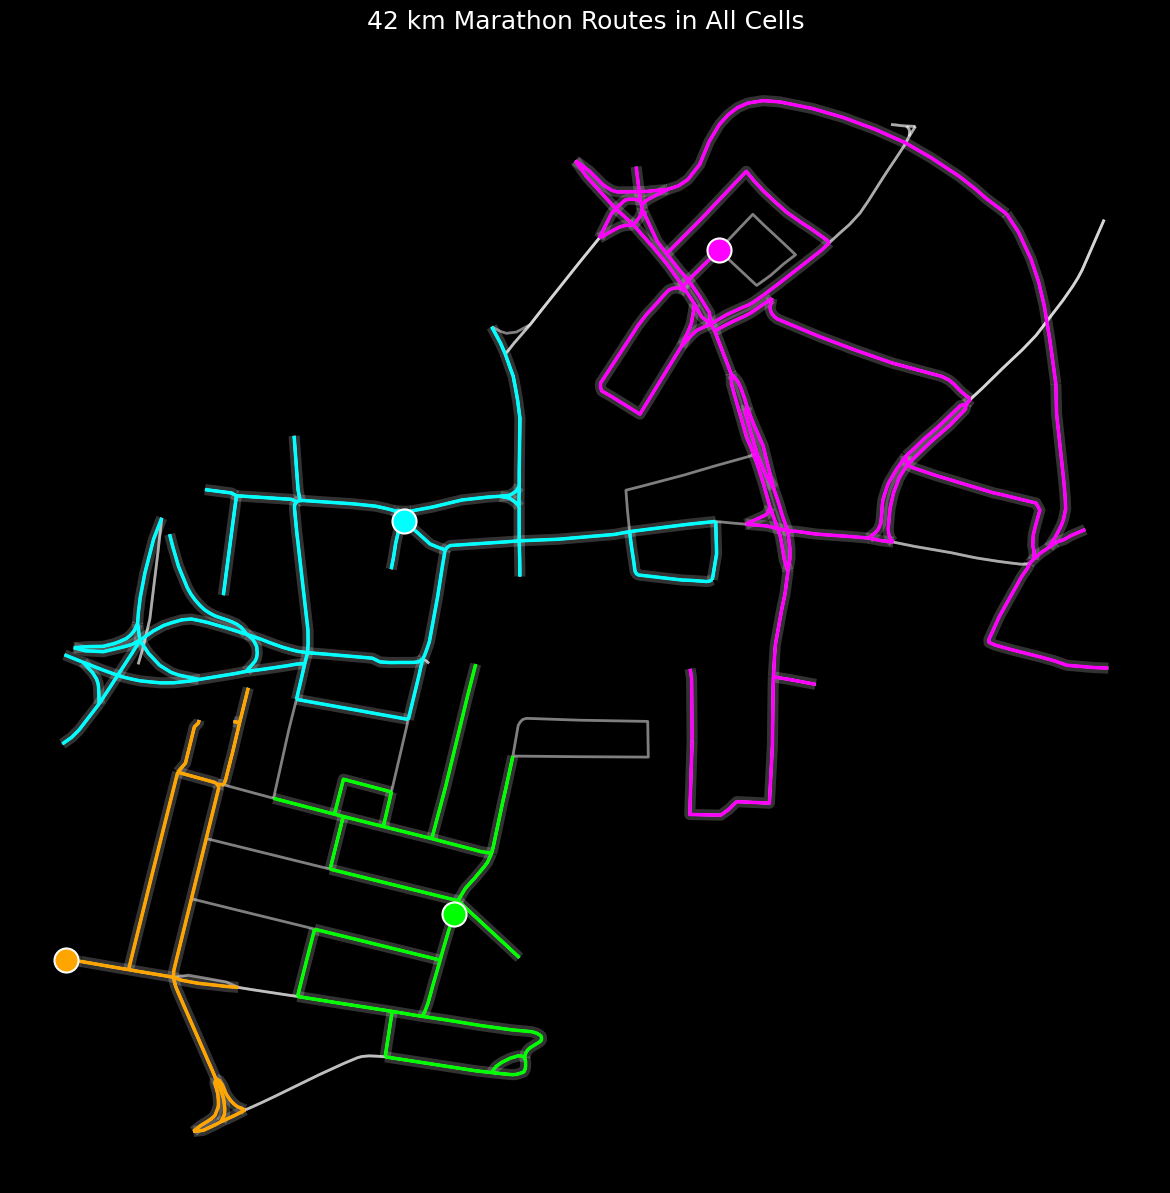

In [34]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.set_facecolor('black')

edges_proj_reset.plot(ax=ax, linewidth=2, edgecolor='white', alpha=0.5)

for seed in seed_node_ids:
    cell_color = seed_to_color[seed]

    subgraph = cell_subgraphs[seed]

    cell_edges_gdf = ox.graph_to_gdfs(subgraph, nodes=False, edges=True).reset_index()

    cell_edges_gdf.plot(
        ax=ax,
        color='white',
        linewidth=2,
        alpha=0.35
    )

    if seed in found_paths_all:
        path_nodes = found_paths_all[seed]
        path_edge_pairs = list(zip(path_nodes, path_nodes[1:]))

        path_edge_set = {tuple(sorted((u, v))) for u, v in path_edge_pairs}

        route_edges_gdf = cell_edges_gdf[
            cell_edges_gdf.apply(
                lambda row: tuple(sorted((row['u'], row['v']))) in path_edge_set,
                axis=1
            )
        ].copy()

        route_edges_gdf.plot(
            ax=ax,
            color='white',
            linewidth=8,
            alpha=0.2
        )

        route_edges_gdf.plot(
            ax=ax,
            color=cell_color,
            linewidth=2.5
        )

    nodes_proj.loc[[seed]].plot(
        ax=ax,
        color=cell_color,
        markersize=300,
        edgecolor='white',
        linewidth=1.5,
        zorder=999
    )

plt.title("42 km Marathon Routes in All Cells", color='white', fontsize=18, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

As visualised in the map, four distinct coloured routes are explicitly overlaid onto the urban grid. Crucially, each route remains strictly confined within its respective Voronoi boundary. This visual and numerical evidence confirms that the mayoral proposal to host four parallel, independent marathons is entirely feasible within the current spatial constraints.

### If there were cells with no such path, what options could increase the number of cells that include such paths? Choose one option, repeat steps 3–4, and report the results.

Although the original four-cell configuration successfully yielded routes for all partitions, it is necessary to establish a contingency methodology should routing fail under stricter operational constraints. To increase the likelihood of finding closed loops in a constrained urban grid, three primary adjustments can be implemented: **1. expanding the global study area to capture more total edges; 2. relocating seed points using alternative network metrics; 3. reducing the total number of seed points**.

This study elected to test the third strategy, **reducing the marathon partitions from four to two**. This approach was chosen because it requires no spatial expansion while directly increasing the internal road density and the number of available edges within each resulting Voronoi cell. From a topological perspective, merging smaller cells significantly expands the search space and increases the cyclomatic complexity of the subgraph, thereby providing the algorithm with a higher volume of valid cyclic structures and fewer forced dead ends.

#### Decrease the Number of Seeds

In [35]:
print("Divide the area into N=2 cells.")

N_marathons_v2 = 2

G_undirected_v2 = G_projected.to_undirected()

closeness_v2 = nx.closeness_centrality(G_undirected_v2)

safe_nodes_v2 = safe_nodes.copy()
safe_nodes_v2['closeness'] = safe_nodes_v2.index.map(closeness_v2)
safe_nodes_sorted_v2 = safe_nodes_v2.sort_values(by='closeness', ascending=False)

seed_node_ids_v2 = []
seed_points_geom_v2 = []
min_distance_v2 = 300

for node_id, row in safe_nodes_sorted_v2.iterrows():
    if len(seed_node_ids_v2) < N_marathons_v2:
        point_current = row.geometry
        is_far_enough = True

        for existing_geom in seed_points_geom_v2:
            if point_current.distance(existing_geom) < min_distance_v2:
                is_far_enough = False
                break

        if is_far_enough:
            seed_node_ids_v2.append(node_id)
            seed_points_geom_v2.append(point_current)
    else:
        break

Divide the area into N=2 cells.


In [36]:
lengths_v2, paths_v2 = nx.multi_source_dijkstra(
    G_undirected_v2,
    sources=seed_node_ids_v2,
    weight='length'
)
node_to_seed_v2 = {node: path[0] for node, path in paths_v2.items()}

In [38]:
found_paths_v2 = {}
colors_v2 = ['cyan', 'magenta']

for seed in seed_node_ids_v2:
    print(f"Calculating a 42 km route for the new cell (seed point {seed})...")

    nodes_in_cell = [n for n, s in node_to_seed_v2.items() if s == seed]
    subgraph_v2 = G_undirected_v2.subgraph(nodes_in_cell).copy()

    path, length = generate_marathon_path(
        subgraph_v2,
        seed,
        target_length=42195,
        tolerance=100
    )

    if path:
        found_paths_v2[seed] = path
        print(f"Path found! Total length: {length / 1000:.2f} km")
    else:
        print("Finding failure.")

Calculating a 42 km route for the new cell (seed point 1862252964)...
Path found! Total length: 42.15 km
Calculating a 42 km route for the new cell (seed point 247352905)...
Path found! Total length: 42.16 km


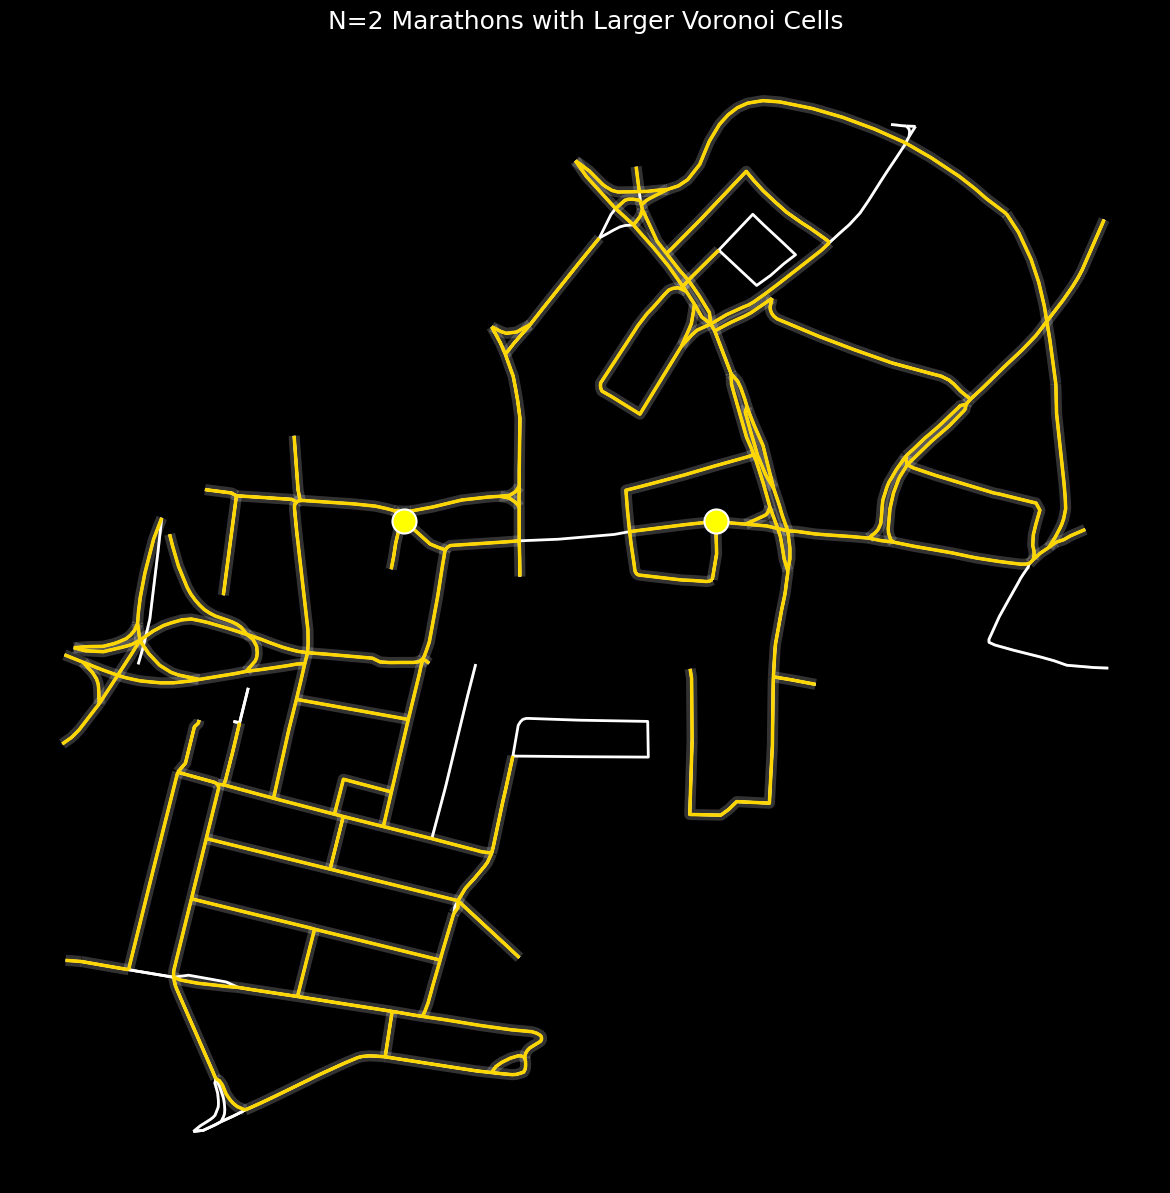

In [39]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.set_facecolor('black')

edges_proj_reset.plot(ax=ax, linewidth=2, edgecolor='white')

for seed in seed_node_ids_v2:
    nodes_in_cell = [n for n, s in node_to_seed_v2.items() if s == seed]
    subgraph_v2 = G_undirected_v2.subgraph(nodes_in_cell).copy()

    cell_edges_gdf_v2 = ox.graph_to_gdfs(subgraph_v2, nodes=False, edges=True).reset_index()

    cell_edges_gdf_v2.plot(
        ax=ax,
        color='white',
        linewidth=2,
        alpha=0.3
    )

    if seed in found_paths_v2:
        path_nodes = found_paths_v2[seed]
        path_edge_pairs = list(zip(path_nodes, path_nodes[1:]))

        path_edge_set = {tuple(sorted((u, v))) for u, v in path_edge_pairs}

        route_edges_gdf_v2 = cell_edges_gdf_v2[
            cell_edges_gdf_v2.apply(
                lambda row: tuple(sorted((row['u'], row['v']))) in path_edge_set,
                axis=1
            )
        ].copy()

        route_edges_gdf_v2.plot(
            ax=ax,
            color='white',
            linewidth=8,
            alpha=0.2
        )

        route_edges_gdf_v2.plot(
            ax=ax,
            color='gold',
            linewidth=2.5
        )

    nodes_proj.loc[[seed]].plot(
        ax=ax,
        color='yellow',
        markersize=300,
        edgecolor='white',
        linewidth=1.5,
        zorder=999
    )

plt.title("N=2 Marathons with Larger Voronoi Cells", color='white', fontsize=18, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

To rigorously validate this structural advantage, **the distance tolerance was tightened from 200 meters down to 100 meters**. The reconfigured two-cell network successfully generated two continuous loops measuring 42.15 kilometers and 42.16 kilometers. This confirms that **reducing the number of partitions effectively enhances the robustness of the pathfinding algorithm**, demonstrating that larger topological cells reliably support stricter distance constraints without requiring repeated routing in confined blocks.

### **Further ideas and alternative approaches can be found in the appendix to the report.**